# 04 — Escalamiento y PCA



In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.preprocessing import StandardScaler
from sklearn.decomposition import PCA

df = pd.read_csv('../data/processed/streaming_users_clean.csv')
ORDEN_PLAN = ['Básico', 'Estándar', 'Premium']

In [2]:
orden_plan = {'Básico': 0, 'Estándar': 1, 'Premium': 2}
df['plan_ordinal'] = df['subscription_plan'].map(orden_plan)

variables = ['age', 'monthly_watch_time_mins', 'customer_support_tickets', 'plan_ordinal']
X = df[variables]

print("Correlación entre las variables seleccionadas:")
print(X.corr().round(3))

Correlación entre las variables seleccionadas:
                            age  monthly_watch_time_mins  \
age                       1.000                    0.004   
monthly_watch_time_mins   0.004                    1.000   
customer_support_tickets  0.007                   -0.002   
plan_ordinal             -0.002                    0.423   

                          customer_support_tickets  plan_ordinal  
age                                          0.007        -0.002  
monthly_watch_time_mins                     -0.002         0.423  
customer_support_tickets                     1.000        -0.001  
plan_ordinal                                -0.001         1.000  


**Interpretación:** antes de aplicar nada, miramos qué variables ya se mueven juntas.
Hay una sola correlación real: `monthly_watch_time_mins` y `plan_ordinal` (r = 0.423) — el
mismo hallazgo de la Pregunta 3 del EDA. `age` y `customer_support_tickets` no se correlacionan
con ninguna otra variable (r ≈ 0). Esto importa para lo que sigue: con solo una relación fuerte
entre 4 variables, no hay que esperar que PCA comprima mucho la información.


## Escalamiento

Las variables están en escalas muy distintas (minutos vs. años vs. cantidad de tickets vs. un
código 0-2), así que antes de PCA hay que escalar — si no, la variable de mayor varianza
numérica domina el resultado sin ninguna razón real (Clase 8).


In [3]:
print("Varianza ANTES de escalar:")
print(X.var().round(2))

scaler = StandardScaler()
X_scaled = scaler.fit_transform(X)
X_scaled_df = pd.DataFrame(X_scaled, columns=variables)

print("\nVarianza DESPUÉS de escalar (StandardScaler):")
print(X_scaled_df.var().round(3))

Varianza ANTES de escalar:
age                            137.03
monthly_watch_time_mins     240363.89
customer_support_tickets         0.80
plan_ordinal                     0.58
dtype: float64

Varianza DESPUÉS de escalar (StandardScaler):
age                         1.0
monthly_watch_time_mins     1.0
customer_support_tickets    1.0
plan_ordinal                1.0
dtype: float64


**Interpretación:** sin escalar, `monthly_watch_time_mins` tiene una varianza de
**240.364**, frente a 137 de `age`, 0.8 de `customer_support_tickets` y 0.58 de
`plan_ordinal` — pesaría casi en solitario en cualquier cálculo de distancia o componente.
Tras `StandardScaler`, las cuatro quedan con varianza 1: ahora compiten en igualdad de
condiciones para que PCA encuentre la estructura real, no la de mayor magnitud.


## PCA — Varianza explicada


In [4]:
pca = PCA()
componentes = pca.fit_transform(X_scaled)

varianza = pca.explained_variance_ratio_ * 100
varianza_acumulada = np.cumsum(varianza)

resumen_pca = pd.DataFrame({
    'Componente': [f'PC{i+1}' for i in range(len(variables))],
    'Varianza explicada (%)': varianza.round(2),
    'Varianza acumulada (%)': varianza_acumulada.round(2)
})
print(resumen_pca.to_string(index=False))

Componente  Varianza explicada (%)  Varianza acumulada (%)
       PC1                   35.58                   35.58
       PC2                   25.17                   60.75
       PC3                   24.83                   85.58
       PC4                   14.42                  100.00


**Interpretación:** no hay un "codo" marcado — la varianza se reparte de forma relativamente
pareja entre las primeras tres componentes (35.6%, 25.2%, 24.8%) y recién cae en la cuarta
(14.4%). Esto es consistente con lo que vimos en la correlación: como solo dos de las cuatro
variables están realmente relacionadas entre sí, PCA no tiene mucha redundancia para comprimir.
Se eligen **2 componentes** para poder visualizar el resultado en un plano, sabiendo que se
conserva el **60.75%** de la varianza total — suficiente para mostrar la separación por plan
que ya identificamos en el EDA, no una reducción exhaustiva de la dimensionalidad original.


## PCA — Interpretación de las componentes (cargas)


                            PC1    PC2    PC3    PC4
age                       0.004  0.708 -0.706 -0.010
monthly_watch_time_mins   0.707  0.004 -0.001  0.707
customer_support_tickets -0.004  0.706  0.708  0.001
plan_ordinal              0.707 -0.004  0.010 -0.707


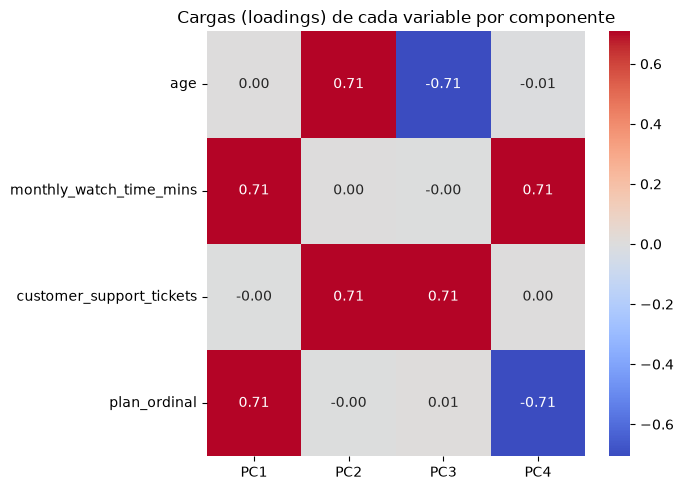

In [5]:
loadings = pd.DataFrame(
    pca.components_.T,
    index=variables,
    columns=[f'PC{i+1}' for i in range(len(variables))]
)
print(loadings.round(3))

plt.figure(figsize=(7, 5))
sns.heatmap(loadings, annot=True, fmt='.2f', cmap='coolwarm', center=0)
plt.title('Cargas (loadings) de cada variable por componente')
plt.tight_layout()
plt.show()

**Interpretación:**

- **PC1 (35.6%)** está dominado por `monthly_watch_time_mins` (0.71) y `plan_ordinal` (0.71),
  con el mismo signo — es el eje "plan + consumo" que ya identificamos en el EDA. Resume en una
  sola dimensión la relación más fuerte del dataset.
- **PC2 (25.2%)** combina `age` (0.71) y `customer_support_tickets` (0.71). A diferencia de
  PC1, esta combinación **no** refleja una relación real entre esas variables (su correlación
  original era ≈ 0). No corresponde interpretarla como "los usuarios mayores
  generan más tickets" — esa relación no existe en los datos.

Esta distinción es importante: PCA encontró **una** estructura real (PC1) y el resto es,
esencialmente, varianza sin correlación que se reparte de forma matemática, no relaciones
nuevas a destacar.


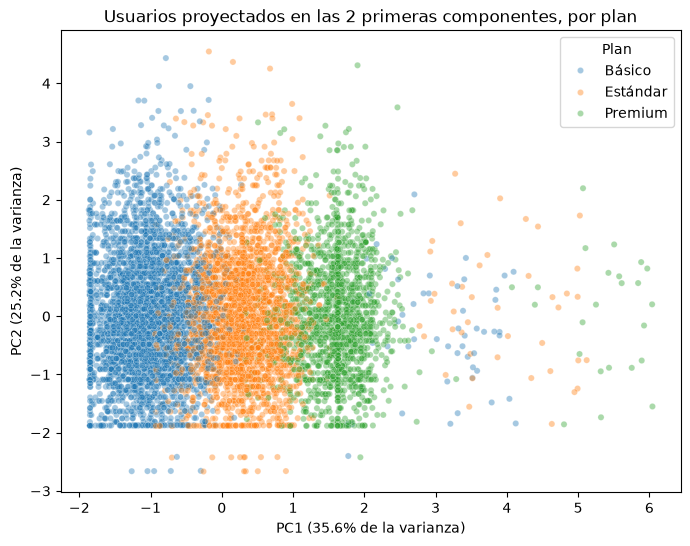

In [8]:
df_pca = pd.DataFrame(componentes[:, :2], columns=['PC1', 'PC2'])
df_pca['subscription_plan'] = df['subscription_plan'].values

plt.figure(figsize=(8, 6))
sns.scatterplot(data=df_pca, x='PC1', y='PC2', hue='subscription_plan',
                 hue_order=ORDEN_PLAN, alpha=0.4, s=20)
plt.title('Usuarios proyectados en las 2 primeras componentes, por plan')
plt.xlabel(f'PC1 ({varianza[0]:.1f}% de la varianza)')
plt.ylabel(f'PC2 ({varianza[1]:.1f}% de la varianza)')
plt.legend(title='Plan')
plt.show()

**Interpretación:** los tres planes se separan con claridad **a lo largo de PC1**
(Básico a la izquierda, Premium a la derecha), confirmando que esa componente captura
correctamente el eje plan-consumo. En cambio, **no hay separación por plan en el eje PC2**
(las tres nubes se superponen verticalmente) — coherente con que PC2 combina variables sin
relación con el plan. PCA no descubrió una segmentación nueva: confirmó, de forma más
compacta, el mismo patrón que ya habíamos encontrado en el EDA.


**Conclusión:** la reducción de dimensionalidad fue modesta porque el dataset tiene poca
redundancia entre variables (solo una correlación real de cuatro variables). El valor de PCA
acá no fue "encontrar algo nuevo", sino confirmar, de forma cuantitativa y visual, que
`subscription_plan` es la variable que mejor organiza el comportamiento de los usuarios —
el mismo hallazgo central del EDA, ahora respaldado por una técnica distinta.